# ¡Hola Ignacio! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Buen trabajo Ignacio! Has completado correctamente todo lo necesario del notebook, realizaste un gran trabajo aplicando los conocimientos de analítica necesarios, se nota que los manejas muy bien. No tengo comentarios de corrección, tu proyecto está aprobado. Felicitaciones por completar el notebook en la primera revisión, mucho éxito en el siguiente sprint!

Saludos!

</div>

----

Importamos todas las librerías que nos pudieran ser útiles para nuestro análisis

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt 
import seaborn as sns

In [2]:
df_companies = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_04.csv')

Usamos describe para tener una idea de las estadísticas que encontraremos dentro de nuestro df

In [3]:
df_companies.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [4]:
df_neighborhoods.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>


Muy bien hecho con la revisión inicial de la data, ahora tenemos los tipos correctos y sabemos con claridad lo que contiene 



</div>

Generamos la primera gráfica, la cual consta en mostrar el top 10 de barrios en donde se finalizaron los viajes

In [5]:
top_10_neighborhoods = (df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10))

In [6]:
top_10_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Al ordenar los barrios por el promedio de viajes finalizados, se observa que los primeros 10 concentran una cantidad significativamente mayor de viajes en comparación con el resto. Esto sugiere que la demanda de taxis en Chicago está fuertemente centralizada en ciertas zonas específicas de la ciudad.

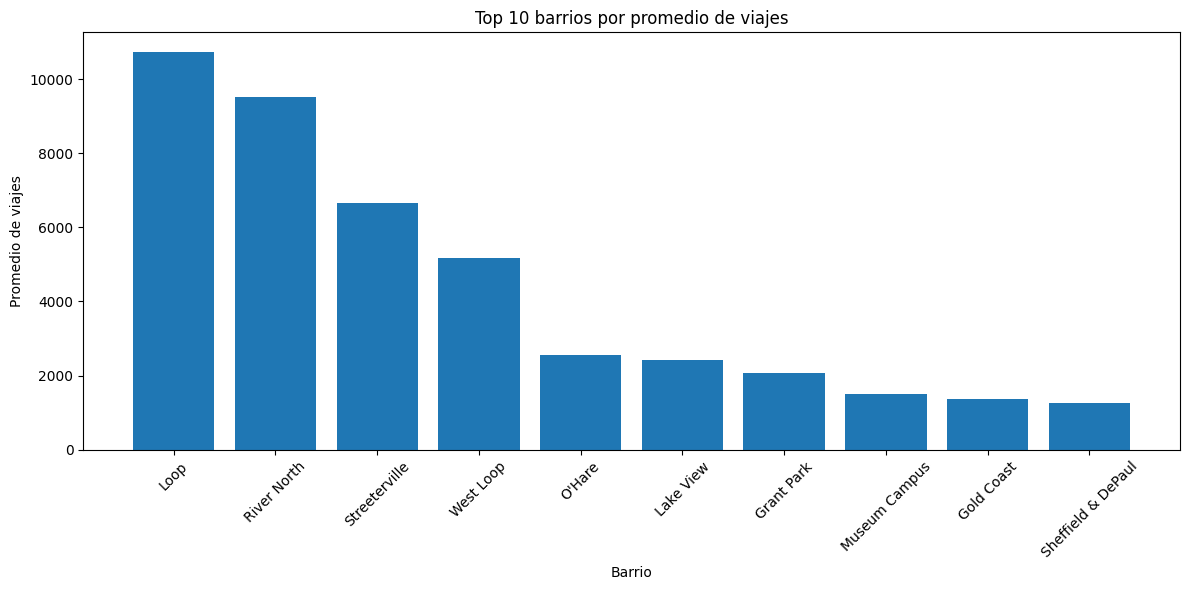

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(
    top_10_neighborhoods['dropoff_location_name'],
    top_10_neighborhoods['average_trips']
)

plt.title('Top 10 barrios por promedio de viajes')
plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Buen trabajo obteniendo el top de barrios! El gráfico está ordenado de mayor a menor, lo que permite notar correctamente que Loop Y River North son los principales destinos. Tal vez tienen atractivos importantes que los hacen lugares de muchas visitas.

</div>

El gráfico muestra que el barrio Loop concentra el mayor promedio de viajes, lo que indica que es el principal destino de los taxis en Chicago. Le siguen River North, Streeterville y West Loop, zonas con alta actividad comercial y turística. La presencia de O’Hare entre los barrios con mayor promedio confirma la relevancia del aeropuerto como destino frecuente. En general, los viajes se concentran en pocas zonas clave, mientras que el resto de los barrios presenta volúmenes considerablemente menores.

In [8]:
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [9]:
top_10_companies = df_companies.sort_values(by='trips_amount',ascending=False).head(10)
    


In [10]:
top_10_companies

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


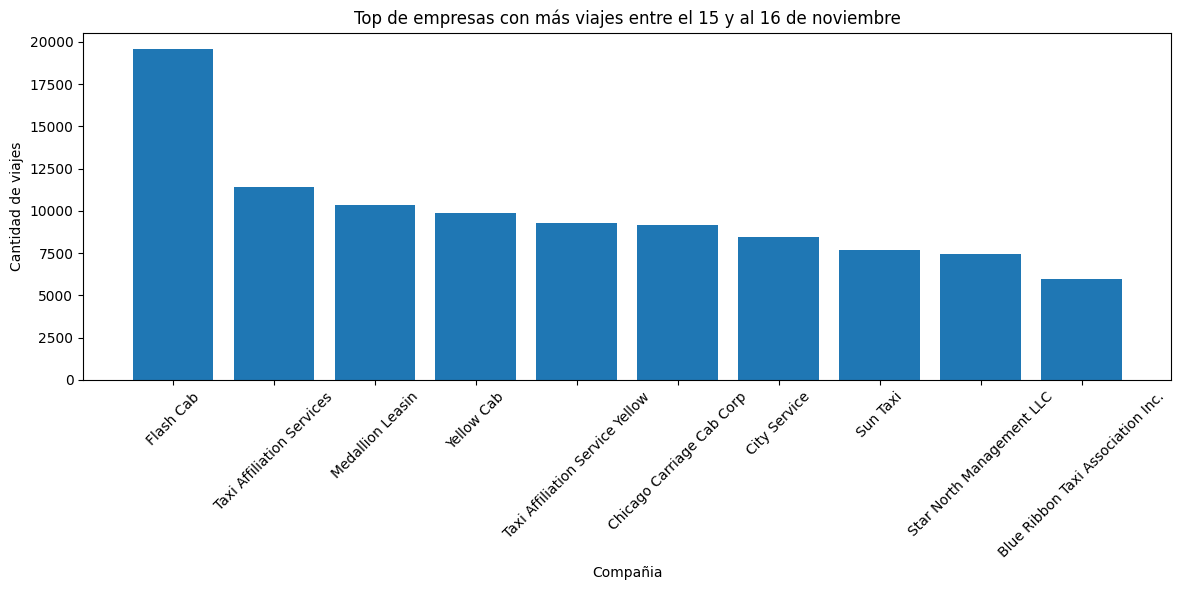

In [11]:


plt.figure(figsize=(12,6))

plt.bar(
    top_10_companies['company_name'],
    top_10_companies['trips_amount']
)

plt.title('Top de empresas con más viajes entre el 15 y al 16 de noviembre')
plt.xlabel('Compañia')
plt.ylabel('Cantidad de viajes')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Muy buen trabajo con la gráfica! Observamos que Flash Cab tiene el liderazgo de cantidad de viajes, bastante más arriba que el competidor que le sigue. Esta concentración de mercado se puede dar por varios factores como cobertura, cantidad de vehículos o buenas estrategias comerciales.

</div>

Flash Cab lidera ampliamente el número de viajes realizados el 15 y 16 de noviembre, con una diferencia considerable respecto al segundo lugar. Esta brecha sugiere una fuerte concentración del mercado en una sola empresa durante el periodo analizado. El resto de las compañías muestran volúmenes relativamente similares entre sí, lo que indica una competencia más equilibrada fuera del líder principal.

Paso 5. Prueba de hipótesis (Python)

Cargamos nuestro archivo para el análisis

In [12]:
df_rides = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_07.csv')

In [13]:
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


Nos damos cuenta que la columna de start_ts esta como object y no en formato de fecha para trabajar con ella, así que realizamos el cambio con ayuda de el metodo .to_datetime para dar formato de fecha a ala columna 'start_ts'

In [14]:
df_rides['start_ts'] = pd.to_datetime(df_rides['start_ts'])

Crearemos también una nueva columna, para conocer los días exactamente en que fue realizado el viaje

In [15]:
df_rides['day_of_week'] = df_rides['start_ts'].dt.day_name()

In [16]:
df_rides

,start_ts,weather_conditions,duration_seconds,day_of_week
0,2017-11-25 16:00:00,Good,2410.0,Saturday
1,2017-11-25 14:00:00,Good,1920.0,Saturday
2,2017-11-25 12:00:00,Good,1543.0,Saturday
3,2017-11-04 10:00:00,Good,2512.0,Saturday
4,2017-11-11 07:00:00,Good,1440.0,Saturday
...,...,...,...,...
1063,2017-11-25 11:00:00,Good,0.0,Saturday
1064,2017-11-11 10:00:00,Good,1318.0,Saturday
1065,2017-11-11 13:00:00,Good,2100.0,Saturday
1066,2017-11-11 08:00:00,Good,1380.0,Saturday


seguido de crear nuestra columna day_of_week uso el método .unique, para saber los días que aparecen, y, como podemos observar, solamente son los días, por lo que ya no será necesario filtrar por días.

In [17]:
df_rides['day_of_week'].unique()

array(['Saturday'], dtype=object)

Vamos ahora a filtrar/separar por grupos, los días lluviosos, es decir cuando el clima fue Bad de los días cuando el clima fue Good

In [18]:
rainy = df_rides[df_rides['weather_conditions'] == 'Bad']['duration_seconds']
not_rainy = df_rides[df_rides['weather_conditions']=='Good']['duration_seconds']

Paso 6. Generamos formalmente nuestra hipótesis.

    "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Ho = 'La duración promedio de los viajes desde el Loop hasta el Aeropuerto O'Hare es igual en sábados es la misma y no depende de si el clima es bueno o malo.'


H1 = '"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".'

In [19]:
α = 0.05


Se estableció un nivel de significación de 0.05, valor comúnmente utilizado en pruebas estadísticas.

In [20]:
results = st.ttest_ind(rainy,not_rainy)

In [21]:
print("t-statistic:", results.statistic)
print("p-value:", results.pvalue)

t-statistic: 6.946177714041499
p-value: 6.517970327099473e-12


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el test de hipótesis, fue realizado de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales. Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es estadísticamente diferente. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).





</div>

In [22]:
rainy.mean()

2427.2055555555557

In [23]:
not_rainy.mean()

1999.6756756756756

In [24]:
if results.pvalue < α:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


Rechazamos la hipótesis nula


Se realizó una prueba t de Student para comparar la duración promedio de los viajes en sábados lluviosos y no lluviosos.
Con un nivel de significancia de 0.05, se obtuvo un p-value de 6.51e-12, que es menor que α.
Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una diferencia estadísticamente significativa en la duración promedio de los viajes.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>

Correcto, muy bien con las conclusiones



</div>